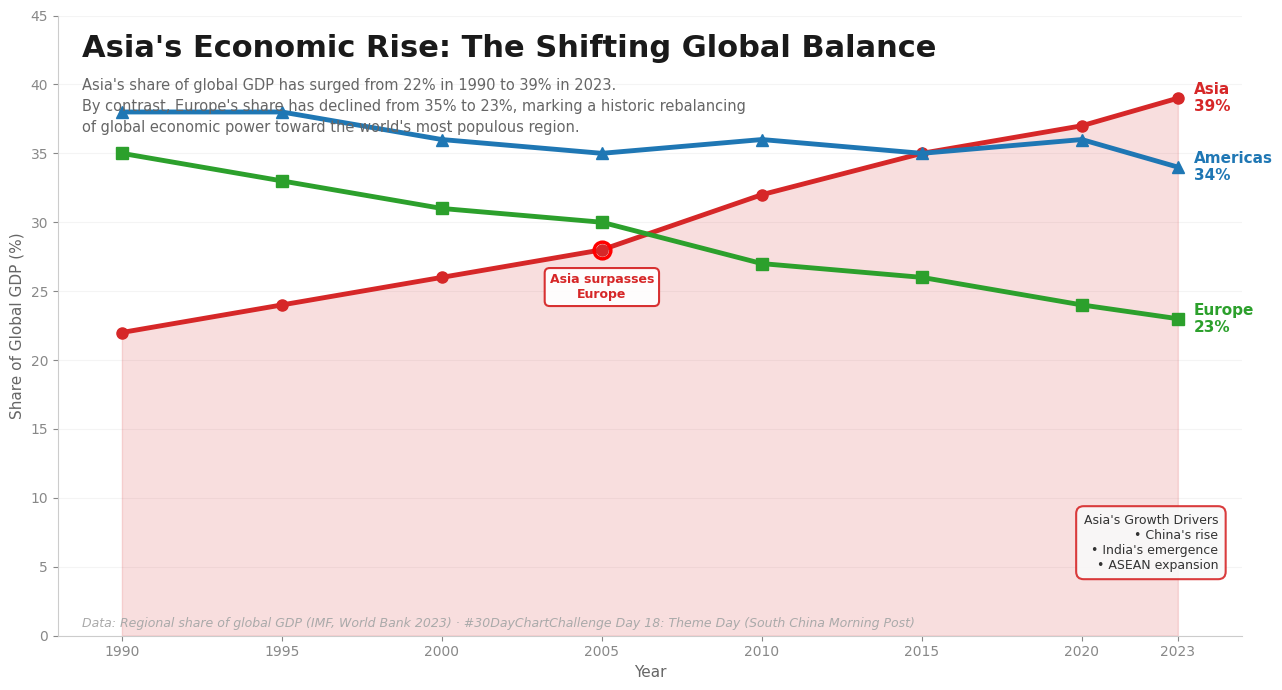

In [1]:
"""
#30DayChartChallenge — Day 18: Theme Day (South China Morning Post)
"Asia's Economic Rise: The Shifting Global Balance" — regional economic dominance
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: Share of global GDP by region over time (1990-2023)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — Regional share of global GDP over time (%)
# ---------------------------------------------------------------------------
data = {
    "Year": [1990, 1995, 2000, 2005, 2010, 2015, 2020, 2023],
    "Asia": [22, 24, 26, 28, 32, 35, 37, 39],
    "Europe": [35, 33, 31, 30, 27, 26, 24, 23],
    "Americas": [38, 38, 36, 35, 36, 35, 36, 34],
    "Africa": [3, 3, 3, 4, 4, 4, 3, 3],
    "Oceania": [2, 2, 2, 2, 2, 2, 2, 2]
}

df = pd.DataFrame(data)

# ---------------------------------------------------------------------------
# 2. PLOT — Area chart showing regional shifts
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 7), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")

# Colors for each region
colors = {
    "Asia": "#d62728",
    "Americas": "#1f77b4",
    "Europe": "#2ca02c",
    "Africa": "#ff7f0e",
    "Oceania": "#9467bd"
}

# Plot lines for each region
ax.plot(df["Year"], df["Asia"], color=colors["Asia"], linewidth=3.5, marker="o", 
        markersize=8, label="Asia", zorder=3)
ax.plot(df["Year"], df["Europe"], color=colors["Europe"], linewidth=3.5, marker="s",
        markersize=8, label="Europe", zorder=3)
ax.plot(df["Year"], df["Americas"], color=colors["Americas"], linewidth=3.5, marker="^",
        markersize=8, label="Americas", zorder=3)

# Fill area under Asia line to highlight rise
ax.fill_between(df["Year"], 0, df["Asia"], color=colors["Asia"], alpha=0.15, zorder=1)

# Direct labels at the end of lines
for region in ["Asia", "Europe", "Americas"]:
    last_year = df["Year"].iloc[-1]
    last_value = df[region].iloc[-1]
    
    ax.text(last_year + 0.5, last_value, f"{region}\n{last_value}%",
            fontsize=11, fontweight="bold", color=colors[region], va="center")

# Highlight the crossover point (when Asia surpassed Europe)
# Find intersection
crossover_idx = None
for i in range(len(df) - 1):
    if df["Asia"].iloc[i] <= df["Europe"].iloc[i] and df["Asia"].iloc[i+1] > df["Europe"].iloc[i+1]:
        crossover_idx = i
        break

if crossover_idx is not None:
    crossover_year = df["Year"].iloc[crossover_idx]
    crossover_value = df["Asia"].iloc[crossover_idx]
    ax.plot(crossover_year, crossover_value, marker="o", markersize=12, 
            color="#ff0000", zorder=5, markerfacecolor="none", markeredgewidth=2.5)
    ax.text(crossover_year, crossover_value - 3.5, "Asia surpasses\nEurope",
            fontsize=9, fontweight="bold", color="#d62728", ha="center",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff", edgecolor="#d62728", linewidth=1.5, alpha=0.95))

# Minimal styling
ax.set_xlim(1988, 2025)
ax.set_ylim(0, 45)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#cccccc")
ax.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, axis="y", zorder=0)
ax.set_axisbelow(True)

ax.set_xlabel("Year", fontsize=11, color="#666666", fontweight="500")
ax.set_ylabel("Share of Global GDP (%)", fontsize=11, color="#666666", fontweight="500")
ax.set_xticks([1990, 1995, 2000, 2005, 2010, 2015, 2020, 2023])
ax.tick_params(colors="#888888", labelsize=10)

# Title & subtitle
ax.text(0.02, 0.97, "Asia's Economic Rise: The Shifting Global Balance",
        fontsize=22, fontweight="bold", color="#1a1a1a", transform=ax.transAxes, va="top")

ax.text(0.02, 0.90,
        "Asia's share of global GDP has surged from 22% in 1990 to 39% in 2023.\n"
        "By contrast, Europe's share has declined from 35% to 23%, marking a historic rebalancing\n"
        "of global economic power toward the world's most populous region.",
        fontsize=10.5, color="#666666", transform=ax.transAxes, va="top", linespacing=1.5)

# Regional context box
ax.text(0.98, 0.15, "Asia's Growth Drivers\n• China's rise\n• India's emergence\n• ASEAN expansion",
        fontsize=9, color="#333333", transform=ax.transAxes, ha="right", va="center",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#f9f9f9", edgecolor="#d62728", linewidth=1.5, alpha=0.9))

# Source
ax.text(0.02, 0.01,
        "Data: Regional share of global GDP (IMF, World Bank 2023) · #30DayChartChallenge Day 18: Theme Day (South China Morning Post)",
        fontsize=9, color="#aaaaaa", style="italic", transform=ax.transAxes, va="bottom")

plt.tight_layout()
plt.savefig("day18_scmp.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()